In [9]:
import psutil

# Obtém informações sobre a memória RAM
memoria = psutil.virtual_memory()

print(f"Total: {memoria.total / (1024**3):.2f} GB")
print(f"Disponível: {memoria.available / (1024**3):.2f} GB")
print(f"Usada: {memoria.used / (1024**3):.2f} GB")
print(f"Percentual de uso: {memoria.percent}%")

Total: 29.96 GB
Disponível: 22.42 GB
Usada: 7.54 GB
Percentual de uso: 25.2%


In [11]:
import os
import pandas as pd
import numpy as np

months = ["jan", ["feb"], "mar", "abr", "may", "jun"] 
mes_escolhido = "jan"

caminho_entrada = os.path.join("..", "data", "telemetry", "processed", f"{mes_escolhido}.csv")

print(f"⏳ Carregando dados do arquivo: {caminho_entrada}...")
df_raw = pd.read_csv(caminho_entrada, low_memory=False)

# Garante a conversão da data e a ordenação cronológica estrita por veículo
df_raw['Data_Evento'] = pd.to_datetime(df_raw['Data_Evento'])
df_raw = df_raw.sort_values(['TAG', 'Data_Evento']).reset_index(drop=True)

# -------------------------------------------------------------------------
# NOVO: CRIAÇÃO DO TARGET PREDITIVO DE 4 HORAS (Evita o Data Leakage)
# -------------------------------------------------------------------------
print("🚨 Calculando janelas de antecedência de 4 horas...")

# 1. Isolamos os eventos de falha real
falhas = df_raw[df_raw['Is_Dont_Go'] == 1][['TAG', 'Data_Evento']].rename(columns={'Data_Evento': 'Data_Falha'})

# -- FIX: Garantimos a ordenação cronológica global para o merge_asof --
df_raw = df_raw.sort_values('Data_Evento')
falhas = falhas.sort_values('Data_Falha')

# 2. Fazemos uma busca temporal "para frente" para descobrir a data da PRÓXIMA falha de cada veículo
df_raw = pd.merge_asof(
    df_raw,
    falhas,
    by='TAG',
    left_on='Data_Evento',
    right_on='Data_Falha',
    direction='forward'
)

# Retornamos à ordenação por TAG para não quebrar a lógica de extração de estados
df_raw = df_raw.sort_values(['TAG', 'Data_Evento']).reset_index(drop=True)

# 3. Calculamos o tempo restante até a falha acontecer (Time to Failure)
df_raw['TTF'] = df_raw['Data_Falha'] - df_raw['Data_Evento']

# 4. O Target será 1 se a falha vai acontecer nas próximas 4 horas 
# (Definimos > 0 segundos para que a própria linha da falha consumada seja 0 e não suje o teste)
df_raw['Target_4h'] = ((df_raw['TTF'] > pd.Timedelta(seconds=0)) & 
                       (df_raw['TTF'] <= pd.Timedelta(hours=4))).astype(int)

# Validação do carregamento
total_registros = df_raw.shape[0]
total_falhas = df_raw['Is_Dont_Go'].sum() if 'Is_Dont_Go' in df_raw.columns else 0
total_preditivo = df_raw['Target_4h'].sum()

print(f"✅ Dados carregados com sucesso: {total_registros} registros encontrados.")
print(f"🚨 Total de eventos críticos no momento exato (Is_Dont_Go = 1): {total_falhas}")
print(f"🎯 Total de eventos em janela de alerta (Antecedência de 4h): {total_preditivo}")

⏳ Carregando dados do arquivo: ../data/telemetry/processed/jan.csv...
🚨 Calculando janelas de antecedência de 4 horas...
✅ Dados carregados com sucesso: 5400002 registros encontrados.
🚨 Total de eventos críticos no momento exato (Is_Dont_Go = 1): 2581
🎯 Total de eventos em janela de alerta (Antecedência de 4h): 187941


In [12]:
import pandas as pd
from collections import deque
from tqdm import tqdm  # <--- Importante!

def extract_markov_transitions(df, window_hours=4, max_seq_len=3):
    """
    Percorre os dados em O(n), mantendo uma janela deslizante cronológica.
    Evita explosão de estados limitando o estado aos últimos `max_seq_len` eventos da janela.
    """
    df = df.sort_values(['TAG', 'Data_Evento']).reset_index(drop=True)
    
    transitions = []
    state_timeline = []
    
    current_tag = None
    window = deque()
    prev_state = None
    
    # Adicionamos a barra de progresso aqui envolvendo o itertuples
    # desc adiciona um texto explicativo ao lado da barra
    for row in tqdm(df.itertuples(), total=len(df), desc="⏳ Processando eventos"):
        tag = row.TAG
        t = row.Data_Evento
        alarm = row.Alarme
        is_dg = row.Is_Dont_Go
        
        if tag != current_tag:
            current_tag = tag
            window.clear()
            prev_state = None
            
        # 1. Deslizamento da janela (Remove eventos fora das últimas 4 horas)
        cutoff_time = t - pd.Timedelta(hours=window_hours)
        while window and window[0][0] < cutoff_time:
            window.popleft()
            
        # 2. Formação do novo estado
        if is_dg == 1:
            new_state = "__DONT_GO__"
        else:
            window.append((t, alarm))
            # O estado é a sequência ordenada (truncada para evitar explosão combinatória)
            recent_alarms = [x[1] for x in window][-max_seq_len:]
            new_state = " -> ".join(recent_alarms)
            
        state_timeline.append(new_state)
        
        # 3. Registrar Transição S(t-1) -> S(t)
        if prev_state is not None:
            transitions.append({"from_state": prev_state, "to_state": new_state})
            
        # 4. Reset se atingir estado absorvente (a cadeia não sai daqui até o conserto)
        if is_dg == 1:
            prev_state = None
            window.clear()
        else:
            prev_state = new_state
            
    df_out = df.copy()
    df_out['state'] = state_timeline
    df_transitions = pd.DataFrame(transitions)
    
    return df_out, df_transitions

# Agora você pode rodar direto, a mensagem já vai aparecer colada na barra de progresso!
df_states, df_transitions = extract_markov_transitions(df_raw, window_hours=4, max_seq_len=3)

⏳ Processando eventos: 100%|██████████| 5400002/5400002 [08:35<00:00, 10467.74it/s]


In [13]:
import numpy as np
import pandas as pd
import psutil  # Garantindo que o psutil esteja disponível para a checagem


class MarkovChainPredictor:
    ABSORBING_STATE = "__DONT_GO__"
    
    def __init__(self, n_steps=5):
        self.n_steps = n_steps
        
    def _print_memory_status(self, etapa: str):
        """Método auxiliar para centralizar o log de RAM e Swap."""
        mem = psutil.virtual_memory()
        swap = psutil.swap_memory()
        
        print(f"\n--- 🧠 [MEMÓRIA] Etapa: {etapa} ---")
        print(f"  RAM   -> Disponível: {mem.available / (1024**3):.2f} GB | Usada: {mem.used / (1024**3):.2f} GB ({mem.percent}%)")
        print(f"  SWAP  -> Total: {swap.total / (1024**3):.2f} GB | Usado: {swap.used / (1024**3):.2f} GB ({swap.percent}%)")
        print("-" * 40)
        
    def fit(self, transitions: pd.DataFrame):
        # Mapeamento do Espaço de Estados
        self._print_memory_status("Início do Mapeamento do Espaço de Estados")
        
        states_set = set(transitions["from_state"].unique()) | set(transitions["to_state"].unique())
        if self.ABSORBING_STATE not in states_set:
            states_set.add(self.ABSORBING_STATE)
            
        self.states_ = sorted(list(states_set))
        self.state_to_idx_ = {s: i for i, s in enumerate(self.states_)}
        self.n_states_ = len(self.states_)
        
        # Construção da Matriz de Contagem O(N)
        self._print_memory_status("Antes de alocar a Matriz de Contagem")
        
        self.count_matrix_ = np.zeros((self.n_states_, self.n_states_))
        from_idx = transitions["from_state"].map(self.state_to_idx_).values
        to_idx = transitions["to_state"].map(self.state_to_idx_).values
        np.add.at(self.count_matrix_, (from_idx, to_idx), 1)
        
        # O estado absorvente não emite transições na contagem (cortamos eventuais ruídos)
        dg_idx = self.state_to_idx_[self.ABSORBING_STATE]
        self.count_matrix_[dg_idx, :] = 0
        
        # Suavização de Laplace (Laplace Smoothing) apenas para estados transientes
        self.count_matrix_ += 1e-6
        self.count_matrix_[dg_idx, :] = 0  # Re-zerar a linha do absorvente
        
        row_sums = self.count_matrix_.sum(axis=1, keepdims=True)
        # Prevenção de Divisão por Zero
        row_sums[row_sums == 0] = 1 
        
        self.P_ = self.count_matrix_ / row_sums
        
        # Forçar propriedade estocástica do estado absorvente (Loop infinito)
        self.P_[dg_idx, dg_idx] = 1.0
        
        # Validação e Cálculo de Risco com monitoramento intermediário
        self._validate_markov_chain()
        
        self._print_memory_status("Antes de calcular a Matriz de Potência (Risco)")
        self._compute_nstep_risk()
        
        self._print_memory_status("Finalização do Fit (Sucesso)")
        return self

    def _validate_markov_chain(self):
        """Relatório de Validação Matemática (Requisito 9)"""
        print("\n" + "="*50)
        print("📐 RELATÓRIO DE VALIDAÇÃO DA CADEIA DE MARKOV")
        print("="*50)
        
        # 1. Soma das linhas (Estocasticidade)
        row_sums = self.P_.sum(axis=1)
        stochastic_valid = np.allclose(row_sums, 1.0)
        print(f"✔ Matriz Estocástica P(linha)=1: {stochastic_valid}")
        
        # 2. Identificação de Estados Inalcançáveis (In-degree nulo)
        col_sums = self.count_matrix_.sum(axis=0)
        unreachable = [self.states_[i] for i in range(self.n_states_) if col_sums[i] <= 1e-5]
        print(f"✔ Estados inalcançáveis (excluindo início): {len(unreachable)}")
        
        # 3. Estados Sem Saída (Dead Ends sem ser absorvente)
        raw_row_sums = (self.count_matrix_ - 1e-6).sum(axis=1)
        dead_ends = [self.states_[i] for i in range(self.n_states_) if raw_row_sums[i] <= 0 and self.states_[i] != self.ABSORBING_STATE]
        print(f"✔ Estados transientes sem saída (Dead ends): {len(dead_ends)}")
        if dead_ends: print(f"  [Aviso] Resolvidos via Smoothing de Laplace.")
        
        # 4. Estados Observados Apenas Uma Vez
        rare_states = [self.states_[i] for i in range(self.n_states_) if 0 < raw_row_sums[i] <= 1]
        print(f"✔ Estados observados apenas 1 vez: {len(rare_states)}")
        
    def _compute_nstep_risk(self):
        """Risco de Absorção em N passos via Matriz de Potência"""
        dg_idx = self.state_to_idx_[self.ABSORBING_STATE]
        # Atenção aqui: np.linalg.matrix_power pode criar cópias temporárias na memória
        P_n = np.linalg.matrix_power(self.P_, self.n_steps)
        self.risk_scores_ = {state: float(P_n[idx, dg_idx]) for state, idx in self.state_to_idx_.items()}

    def predict_proba(self, states: pd.Series) -> np.ndarray:
        known_values = list(self.risk_scores_.values())
        default = float(np.median(known_values)) if known_values else 0.0
        return np.array([self.risk_scores_.get(s, default) for s in states])

In [14]:
import pandas as pd
import psutil
from tqdm import tqdm

def print_script_memory_status(etapa: str):
    mem = psutil.virtual_memory()
    swap = psutil.swap_memory()
    print(f"\n📈 [MEMÓRIA SCRIPT] - {etapa}")
    print(f"   RAM  -> Disponível: {mem.available / (1024**3):.2f} GB | Usada: {mem.used / (1024**3):.2f} GB ({mem.percent}%)")
    print(f"   SWAP -> Total: {swap.total / (1024**3):.2f} GB | Usado: {swap.used / (1024**3):.2f} GB ({swap.percent}%)")
    print("-" * 50)

tqdm.pandas(desc="🔥 Calculando Risco")

print_script_memory_status("Início do Processamento (Carga inicial do df_states)")

# Divisão cronológica
split_date = df_states["Data_Evento"].quantile(0.70)
df_train = df_states[df_states["Data_Evento"] <= split_date].copy()
df_test = df_states[df_states["Data_Evento"] > split_date].copy()

print_script_memory_status("Após Divisão de Treino / Teste")

# Extração de transições apenas no treino
print("⏳ Extraindo transições de treino...")
_, train_transitions = extract_markov_transitions(df_train, window_hours=4, max_seq_len=3)

print_script_memory_status("Após a Extração de Transições")

print("\n⏳ Treinando o modelo...")
# AJUSTE: n_steps aumentado para conseguir olhar para frente na matriz de transição
# Se em 4 horas ocorrem em média 20 alarmes, n_steps=20 é um ótimo ponto de partida.
mc_model = MarkovChainPredictor(n_steps=20) 
mc_model.fit(train_transitions)

print_script_memory_status("Após o Modelo Concluir o .fit()")

print("\n⏳ Aplicando Predições Vetorizadas no Conjunto de Teste...")
# Correção de performance: predict_proba direto na Series substitui o lento progress_apply
df_test["risk_score"] = mc_model.predict_proba(df_test['state']).astype(float)

print_script_memory_status("Após Aplicação das Predições")




📈 [MEMÓRIA SCRIPT] - Início do Processamento (Carga inicial do df_states)
   RAM  -> Disponível: 16.56 GB | Usada: 13.40 GB (44.7%)
   SWAP -> Total: 64.00 GB | Usado: 26.55 GB (41.5%)
--------------------------------------------------

📈 [MEMÓRIA SCRIPT] - Após Divisão de Treino / Teste
   RAM  -> Disponível: 15.12 GB | Usada: 14.84 GB (49.5%)
   SWAP -> Total: 64.00 GB | Usado: 26.40 GB (41.3%)
--------------------------------------------------
⏳ Extraindo transições de treino...


⏳ Processando eventos: 100%|██████████| 3780001/3780001 [05:54<00:00, 10665.53it/s]



📈 [MEMÓRIA SCRIPT] - Após a Extração de Transições
   RAM  -> Disponível: 14.28 GB | Usada: 15.68 GB (52.3%)
   SWAP -> Total: 64.00 GB | Usado: 26.21 GB (41.0%)
--------------------------------------------------

⏳ Treinando o modelo...

--- 🧠 [MEMÓRIA] Etapa: Início do Mapeamento do Espaço de Estados ---
  RAM   -> Disponível: 14.29 GB | Usada: 15.67 GB (52.3%)
  SWAP  -> Total: 64.00 GB | Usado: 5.39 GB (8.4%)
----------------------------------------

--- 🧠 [MEMÓRIA] Etapa: Antes de alocar a Matriz de Contagem ---
  RAM   -> Disponível: 14.36 GB | Usada: 15.60 GB (52.1%)
  SWAP  -> Total: 64.00 GB | Usado: 5.39 GB (8.4%)
----------------------------------------

📐 RELATÓRIO DE VALIDAÇÃO DA CADEIA DE MARKOV
✔ Matriz Estocástica P(linha)=1: True
✔ Estados inalcançáveis (excluindo início): 0
✔ Estados transientes sem saída (Dead ends): 1
  [Aviso] Resolvidos via Smoothing de Laplace.
✔ Estados observados apenas 1 vez: 16621

--- 🧠 [MEMÓRIA] Etapa: Antes de calcular a Matriz de Potênci

In [15]:
# Top Risco dos estados mapeados
df_risk = pd.DataFrame(list(mc_model.risk_scores_.items()), columns=["Estado (Sequência de Alarmes)", "Probabilidade Falha"])
print("\n🔥 TOP 10 Estados com Maior Risco de Absorção (Falha):")
print(df_risk.sort_values("Probabilidade Falha", ascending=False).head(10).to_string(index=False))


🔥 TOP 10 Estados com Maior Risco de Absorção (Falha):
                                                                                     Estado (Sequência de Alarmes)  Probabilidade Falha
                                                                                                       __DONT_GO__             1.000000
                                                                            Right Front Brake Temperature - Active             0.982408
                                                      Start Motor Relay - Active -> Engine Coolant Flow - Inactive             0.982408
  Rx Channel A Not Receiving Messages -> Rx Channel B Not Receiving Messages -> Coolant Outlet Pressure - Inactive             0.982408
Right Rear Brake Temperature - Active -> Left Front Brake Temperature - Active -> MC - TEMPERATURA DA DIREÇÃO >95C             0.982408
                                                                  Aftercooler Level - Active -> Body Up -> Body Up             0.

--- Otimização do Limiar (Threshold) para Janela Preditiva de 4h ---
Melhor Threshold Matemático Calibrado: 0.0259
F1-Score Esperado na Janela: 0.3594
Recall Esperado (Sensibilidade): 0.5920
Precisão Esperada (Confiança): 0.2580

--- Relatório de Classificação Real (Antecedência de 4h) ---
                                  precision    recall  f1-score   support

  Classe 0 (Estável / Sem Falha)       0.98      0.93      0.96   1557855
Classe 1 (Alerta de Falha em 4h)       0.26      0.59      0.36     61233

                        accuracy                           0.92   1619088
                       macro avg       0.62      0.76      0.66   1619088
                    weighted avg       0.96      0.92      0.93   1619088



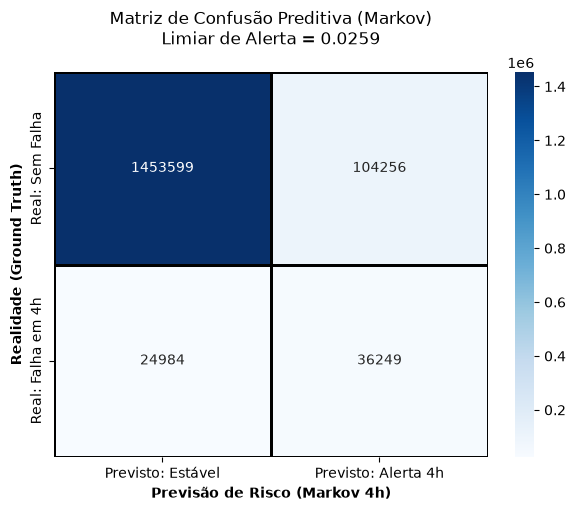

✅ Nova avaliação preditiva salva com sucesso em: ../resultados/jan/


In [18]:
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, accuracy_score, precision_recall_fscore_support
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("--- Otimização do Limiar (Threshold) para Janela Preditiva de 4h ---")

# 1. FILTRAGEM CRUCIAL: Remove os registros onde a falha já aconteceu (Is_Dont_Go == 1)
# Queremos avaliar a capacidade do modelo de prever o FUTURO usando apenas os ALARMES.
df_test_eval = df_test[df_test['Is_Dont_Go'] == 0].copy()

y_pred_prob = df_test_eval['risk_score'].values
y_test = df_test_eval['Target_4h'].fillna(0).astype(int).values 

# 2. Encontrar o limiar matemático ideal através da curva Precision-Recall
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob)

# Calcula o F1-Score para cada threshold da curva
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

# Pega o índice do melhor ponto de equilíbrio
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Melhor Threshold Matemático Calibrado: {best_threshold:.4f}")
print(f"F1-Score Esperado na Janela: {f1_scores[best_idx]:.4f}")
print(f"Recall Esperado (Sensibilidade): {recalls[best_idx]:.4f}")
print(f"Precisão Esperada (Confiança): {precisions[best_idx]:.4f}\n")

# Aplica o threshold calibrado para o horizonte preditivo
y_pred = (y_pred_prob >= best_threshold).astype(int)

# 3. Exibir o Relatório de Classificação Real
print("--- Relatório de Classificação Real (Antecedência de 4h) ---")
print(classification_report(y_test, y_pred, target_names=['Classe 0 (Estável / Sem Falha)', 'Classe 1 (Alerta de Falha em 4h)']))

# 4. Plotar e Salvar a Nova Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='black',
            xticklabels=['Previsto: Estável', 'Previsto: Alerta 4h'], 
            yticklabels=['Real: Sem Falha', 'Real: Falha em 4h'])
plt.ylabel('Realidade (Ground Truth)', fontweight='bold')
plt.xlabel('Previsão de Risco (Markov 4h)', fontweight='bold')
plt.title(f'Matriz de Confusão Preditiva (Markov)\nLimiar de Alerta = {best_threshold:.4f}', pad=20, fontsize=12)

# Pasta de resultados
mes_escolhido = "jan" if "mes_escolhido" not in locals() else mes_escolhido
pasta_resultados = os.path.join('..', 'resultados', mes_escolhido)
os.makedirs(pasta_resultados, exist_ok=True)

plt.savefig(os.path.join(pasta_resultados, f'{mes_escolhido}_markov_4h_matriz_confusao.png'), bbox_inches='tight', dpi=300)
plt.show()

# 5. Salva as novas métricas reais em CSV
acc = accuracy_score(y_test, y_pred)
precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred, average=None)

df_metricas = pd.DataFrame({
    'Metrica': ['Acurácia (Global)', 'Precisão (Estável)', 'Precisão (Alerta 4h)', 
                'Recall (Estável)', 'Recall (Alerta 4h)', 'F1-Score (Estável)', 'F1-Score (Alerta 4h)'],
    'Valor': [acc, precision[0], precision[1], recall[0], recall[1], f1[0], f1[1]]
})
df_metricas.to_csv(os.path.join(pasta_resultados, f'{mes_escolhido}_markov_4h_metricas.csv'), index=False)
print(f"✅ Nova avaliação preditiva salva com sucesso em: {pasta_resultados}/")

In [20]:
import os
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report, precision_recall_fscore_support, accuracy_score

# 1. Lista apenas com os próximos meses (já que 'jan' já foi treinado e avaliado)
meses_restantes = ["feb", "mar", "abr", "may", "jun"]

# Garantir que o modelo existe na memória antes de rodar
if 'mc_model' not in locals():
    raise NameError("❌ O objeto 'mc_model' não foi encontrado na memória. Certifique-se de não ter reiniciado o kernel.")

for mes in meses_restantes:
    print("\n" + "="*60)
    print(f"🔮 AVALIANDO MODELO DE JANEIRO NO MÊS: {mes.upper()}")
    print("="*60)
    
    caminho_entrada = os.path.join("..", "data", "telemetry", "processed", f"{mes}.csv")
    
    if not os.path.exists(caminho_entrada):
        print(f"⚠️ Arquivo {caminho_entrada} não encontrado. Pulando...")
        continue
        
    try:
        # --- ETAPA 1: CARREGAMENTO E CRIAÇÃO DO TARGET ---
        print(f"⏳ Carregando dados de: {caminho_entrada}...")
        df_raw = pd.read_csv(caminho_entrada, low_memory=False)
        
        df_raw['Data_Evento'] = pd.to_datetime(df_raw['Data_Evento'])
        df_raw = df_raw.sort_values(['TAG', 'Data_Evento']).reset_index(drop=True)
        
        # Cruzamento temporal para achar a próxima falha (Evitando Data Leakage)
        falhas = df_raw[df_raw['Is_Dont_Go'] == 1][['TAG', 'Data_Evento']].rename(columns={'Data_Evento': 'Data_Falha'})
        df_raw = df_raw.sort_values('Data_Evento')
        falhas = falhas.sort_values('Data_Falha')
        
        df_raw = pd.merge_asof(
            df_raw, falhas, by='TAG', 
            left_on='Data_Evento', right_on='Data_Falha', 
            direction='forward'
        )
        
        df_raw = df_raw.sort_values(['TAG', 'Data_Evento']).reset_index(drop=True)
        df_raw['TTF'] = df_raw['Data_Falha'] - df_raw['Data_Evento']
        df_raw['Target_4h'] = ((df_raw['TTF'] > pd.Timedelta(seconds=0)) & 
                               (df_raw['TTF'] <= pd.Timedelta(hours=4))).astype(int)
        
        # --- ETAPA 2: EXTRAÇÃO DOS ESTADOS DE MARKOV ---
        print("🚨 Extraindo sequência de estados do mês corrente...")
        # Como o modelo já está treinado, usamos o mês completo para teste/validação
        df_states, _ = extract_markov_transitions(df_raw, window_hours=4, max_seq_len=3)
        
        # --- ETAPA 3: PREDIÇÃO COM O MODELO JÁ TREINADO ---
        print("⏳ Aplicando o modelo de Markov pré-treinado (Predict Proba)...")
        df_states["risk_score"] = mc_model.predict_proba(df_states['state']).astype(float)
        
        # --- ETAPA 4: FILTRAGEM E CALIBRAÇÃO DO LIMIAR ---
        # Remove registros onde a falha já aconteceu para avaliar o horizonte futuro
        df_eval = df_states[df_states['Is_Dont_Go'] == 0].copy()
        y_pred_prob = df_eval['risk_score'].values
        y_test = df_eval['Target_4h'].fillna(0).astype(int).values
        
        # Otimiza o threshold especificamente para a distribuição deste mês
        precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob)
        f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
        best_idx = np.argmax(f1_scores)
        best_threshold = thresholds[best_idx]
        
        y_pred = (y_pred_prob >= best_threshold).astype(int)
        
        # --- ETAPA 5: EXIBIÇÃO E SALVAMENTO DOS RESULTADOS ---
        pasta_resultados = os.path.join('..', 'resultados', mes)
        os.makedirs(pasta_resultados, exist_ok=True)
        
        # 1. Matriz de Confusão
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(7,5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='black',
                    xticklabels=['Previsto: Estável', 'Previsto: Alerta 4h'], 
                    yticklabels=['Real: Sem Falha', 'Real: Falha em 4h'])
        plt.ylabel('Realidade (Ground Truth)', fontweight='bold')
        plt.xlabel('Previsão de Risco (Markov 4h)', fontweight='bold')
        plt.title(f'Matriz de Confusão Preditiva - Mês: {mes.upper()}\n(Modelo Treinado em Jan) | Limiar = {best_threshold:.4f}', pad=20)
        
        plt.savefig(os.path.join(pasta_resultados, f'{mes}_markov_4h_matriz_confusao.png'), bbox_inches='tight', dpi=300)
        plt.close()
        
        # 2. Salvar Métricas em CSV
        acc = accuracy_score(y_test, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)
        
        df_metricas = pd.DataFrame({
            'Metrica': ['Acurácia (Global)', 'Precisão (Estável)', 'Precisão (Alerta 4h)', 
                        'Recall (Estável)', 'Recall (Alerta 4h)', 'F1-Score (Estável)', 'F1-Score (Alerta 4h)'],
            'Valor': [acc, precision[0], precision[1], recall[0], recall[1], f1[0], f1[1]]
        })
        df_metricas.to_csv(os.path.join(pasta_resultados, f'{mes}_markov_4h_metricas.csv'), index=False)
        
        print(f"✨ Avaliação concluída com sucesso! Resultados salvos em: {pasta_resultados}/")
        
    except Exception as e:
        print(f"❌ Erro ao processar o mês {mes.upper()}: {str(e)}")
        
    finally:
        # Limpeza cirúrgica de memória RAM
        try:
            del df_raw, df_states, df_eval
        except NameError:
            pass
        gc.collect()

print("\n🏁 [FIM] O modelo existente foi aplicado com sucesso em todos os meses seguintes!")



🔮 AVALIANDO MODELO DE JANEIRO NO MÊS: FEB
⏳ Carregando dados de: ../data/telemetry/processed/feb.csv...
🚨 Extraindo sequência de estados do mês corrente...


⏳ Processando eventos: 100%|██████████| 5709935/5709935 [10:30<00:00, 9055.38it/s] 


⏳ Aplicando o modelo de Markov pré-treinado (Predict Proba)...
✨ Avaliação concluída com sucesso! Resultados salvos em: ../resultados/feb/

🔮 AVALIANDO MODELO DE JANEIRO NO MÊS: MAR
⏳ Carregando dados de: ../data/telemetry/processed/mar.csv...
🚨 Extraindo sequência de estados do mês corrente...


⏳ Processando eventos: 100%|██████████| 5688538/5688538 [08:26<00:00, 11227.63it/s]


⏳ Aplicando o modelo de Markov pré-treinado (Predict Proba)...
✨ Avaliação concluída com sucesso! Resultados salvos em: ../resultados/mar/

🔮 AVALIANDO MODELO DE JANEIRO NO MÊS: ABR
⏳ Carregando dados de: ../data/telemetry/processed/abr.csv...
🚨 Extraindo sequência de estados do mês corrente...


...

⏳ Aplicando o modelo de Markov pré-treinado (Predict Proba)...
✨ Avaliação concluída com sucesso! Resultados salvos em: ../resultados/abr/

🔮 AVALIANDO MODELO DE JANEIRO NO MÊS: MAY
⏳ Carregando dados de: ../data/telemetry/processed/may.csv...
🚨 Extraindo sequência de estados do mês corrente...


⏳ Processando eventos: 100%|██████████| 6036291/6036291 [08:45<00:00, 11481.25it/s]


⏳ Aplicando o modelo de Markov pré-treinado (Predict Proba)...
✨ Avaliação concluída com sucesso! Resultados salvos em: ../resultados/may/

🔮 AVALIANDO MODELO DE JANEIRO NO MÊS: JUN
⏳ Carregando dados de: ../data/telemetry/processed/jun.csv...
🚨 Extraindo sequência de estados do mês corrente...


⏳ Processando eventos:  79%|███████▉  | 6199421/7854243 [1:47:30<28:41, 961.15it/s]  


KeyboardInterrupt: 

🔮 EXECUTANDO AVALIAÇÃO OTIMIZADA PARA O MÊS: JUN
⏳ Carregando dados de: ../data/telemetry/processed/jun.csv...
🚨 Extraindo estados com o novo algoritmo O(1)...


⏳ Processando eventos: 100%|██████████| 7854243/7854243 [01:01<00:00, 128412.55it/s]


⏳ Aplicando predições com o modelo carregado...

--- Relatório de Classificação Real (Mês: JUN) ---
                      precision    recall  f1-score   support

  Classe 0 (Estável)       0.99      1.00      1.00   7785149
Classe 1 (Alerta 4h)       0.60      0.21      0.31     63868

            accuracy                           0.99   7849017
           macro avg       0.80      0.60      0.65   7849017
        weighted avg       0.99      0.99      0.99   7849017



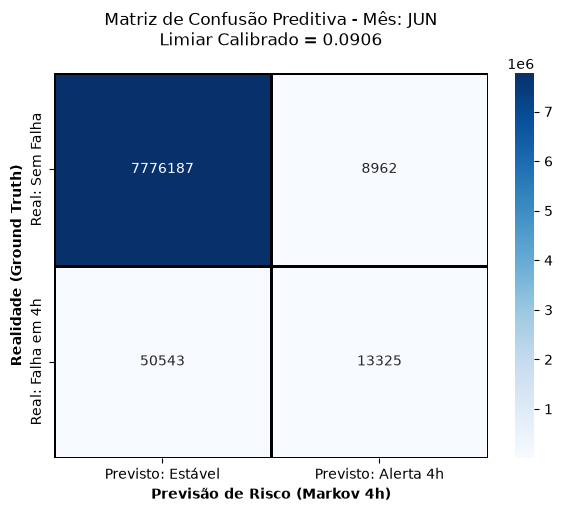

✨ Pronto! Avaliação de Junho salva com sucesso em: ../resultados/jun/


In [22]:
import os
import gc
import pandas as pd
import numpy as np
from collections import deque
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report, precision_recall_fscore_support, accuracy_score

# -------------------------------------------------------------------------
# CORREÇÃO CRUCIAL: Otimização O(1) da extração de transições de Markov
# -------------------------------------------------------------------------
def extract_markov_transitions(df, window_hours=4, max_seq_len=3):
    df = df.sort_values(['TAG', 'Data_Evento']).reset_index(drop=True)
    
    transitions = []
    state_timeline = []
    
    current_tag = None
    window = deque()
    prev_state = None
    
    for row in tqdm(df.itertuples(), total=len(df), desc="⏳ Processando eventos"):
        tag = row.TAG
        t = row.Data_Evento
        alarm = row.Alarme
        is_dg = row.Is_Dont_Go
        
        if tag != current_tag:
            current_tag = tag
            window.clear()
            prev_state = None
            
        # 1. Deslizamento da janela (Remove eventos fora das últimas 4 horas)
        cutoff_time = t - pd.Timedelta(hours=window_hours)
        while window and window[0][0] < cutoff_time:
            window.popleft()
            
        # 2. Formação do novo estado
        if is_dg == 1:
            new_state = "__DONT_GO__"
        else:
            window.append((t, alarm))
            
            # --- FIX SUPER ULTRA OTIMIZADO ---
            # Em vez de ler a janela inteira, acessamos direto os últimos N elementos por índice invertido
            w_len = len(window)
            take = min(w_len, max_seq_len)
            recent_alarms = [window[w_len - i][1] for i in range(take, 0, -1)]
            new_state = " -> ".join(recent_alarms)
            
        state_timeline.append(new_state)
        
        # 3. Registrar Transição S(t-1) -> S(t)
        if prev_state is not None:
            transitions.append({"from_state": prev_state, "to_state": new_state})
            
        # 4. Reset se atingir estado absorvente
        if is_dg == 1:
            prev_state = None
            window.clear()
        else:
            prev_state = new_state
            
    df_out = df.copy()
    df_out['state'] = state_timeline
    df_transitions = pd.DataFrame(transitions)
    
    return df_out, df_transitions


# -------------------------------------------------------------------------
# EXECUÇÃO DO MÊS DE JUNHO
# -------------------------------------------------------------------------
mes = "jun"

if 'mc_model' not in locals():
    raise NameError("❌ O objeto 'mc_model' não foi encontrado. Certifique-se de não ter reiniciado o Kernel do zero.")

print("="*60)
print(f"🔮 EXECUTANDO AVALIAÇÃO OTIMIZADA PARA O MÊS: {mes.upper()}")
print("="*60)

caminho_entrada = os.path.join("..", "data", "telemetry", "processed", f"{mes}.csv")

try:
    print(f"⏳ Carregando dados de: {caminho_entrada}...")
    df_raw = pd.read_csv(caminho_entrada, low_memory=False)
    
    df_raw['Data_Evento'] = pd.to_datetime(df_raw['Data_Evento'])
    df_raw = df_raw.sort_values(['TAG', 'Data_Evento']).reset_index(drop=True)
    
    # Alinhamento temporal contra Data Leakage
    falhas = df_raw[df_raw['Is_Dont_Go'] == 1][['TAG', 'Data_Evento']].rename(columns={'Data_Evento': 'Data_Falha'})
    df_raw = df_raw.sort_values('Data_Evento')
    falhas = falhas.sort_values('Data_Falha')
    
    df_raw = pd.merge_asof(df_raw, falhas, by='TAG', left_on='Data_Evento', right_on='Data_Falha', direction='forward')
    df_raw = df_raw.sort_values(['TAG', 'Data_Evento']).reset_index(drop=True)
    df_raw['TTF'] = df_raw['Data_Falha'] - df_raw['Data_Evento']
    df_raw['Target_4h'] = ((df_raw['TTF'] > pd.Timedelta(seconds=0)) & (df_raw['TTF'] <= pd.Timedelta(hours=4))).astype(int)
    
    # Extração corrigida
    print("🚨 Extraindo estados com o novo algoritmo O(1)...")
    df_states, _ = extract_markov_transitions(df_raw, window_hours=4, max_seq_len=3)
    
    print("⏳ Aplicando predições com o modelo carregado...")
    df_states["risk_score"] = mc_model.predict_proba(df_states['state']).astype(float)
    
    df_eval = df_states[df_states['Is_Dont_Go'] == 0].copy()
    y_pred_prob = df_eval['risk_score'].values
    y_test = df_eval['Target_4h'].fillna(0).astype(int).values
    
    # Otimização do limiar
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    
    y_pred = (y_pred_prob >= best_threshold).astype(int)
    
    # Resultados
    pasta_resultados = os.path.join('..', 'resultados', mes)
    os.makedirs(pasta_resultados, exist_ok=True)
    
    print(f"\n--- Relatório de Classificação Real (Mês: {mes.upper()}) ---")
    print(classification_report(y_test, y_pred, target_names=['Classe 0 (Estável)', 'Classe 1 (Alerta 4h)']))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(7,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='black',
                xticklabels=['Previsto: Estável', 'Previsto: Alerta 4h'], 
                yticklabels=['Real: Sem Falha', 'Real: Falha em 4h'])
    plt.ylabel('Realidade (Ground Truth)', fontweight='bold')
    plt.xlabel('Previsão de Risco (Markov 4h)', fontweight='bold')
    plt.title(f'Matriz de Confusão Preditiva - Mês: {mes.upper()}\nLimiar Calibrado = {best_threshold:.4f}', pad=20)
    
    plt.savefig(os.path.join(pasta_resultados, f'{mes}_markov_4h_matriz_confusao.png'), bbox_inches='tight', dpi=300)
    plt.show()
    
    acc = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)
    
    df_metricas = pd.DataFrame({
        'Metrica': ['Acurácia (Global)', 'Precisão (Estável)', 'Precisão (Alerta 4h)', 
                    'Recall (Estável)', 'Recall (Alerta 4h)', 'F1-Score (Estável)', 'F1-Score (Alerta 4h)'],
        'Valor': [acc, precision[0], precision[1], recall[0], recall[1], f1[0], f1[1]]
    })
    df_metricas.to_csv(os.path.join(pasta_resultados, f'{mes}_markov_4h_metricas.csv'), index=False)
    print(f"✨ Pronto! Avaliação de Junho salva com sucesso em: {pasta_resultados}/")

except Exception as e:
    print(f"❌ Erro crítico: {str(e)}")
finally:
    try: del df_raw, df_states, df_eval
    except NameError: pass
    gc.collect()

In [23]:
import os
import gc
import pandas as pd
from collections import deque
from tqdm import tqdm

# 1. Carregamento dos dados de Junho
caminho_jun = os.path.join("..", "data", "telemetry", "processed", "jun.csv")
print("⏳ Carregando dados de Junho para diagnóstico de performance...")
df_jun = pd.read_csv(caminho_jun, low_memory=False)

df_jun['Data_Evento'] = pd.to_datetime(df_jun['Data_Evento'])
df_jun = df_jun.sort_values(['TAG', 'Data_Evento']).reset_index(drop=True)

# 2. Simulação ultra-rápida do tamanho da janela deslizante
print("🔍 Analisando volumetria das janelas de 4 horas...")
window = deque()
current_tag = None
historico_tamanhos = []

for row in tqdm(df_jun.itertuples(), total=len(df_jun), desc="📊 Rastreando tamanho da janela"):
    tag = row.TAG
    t = row.Data_Evento
    is_dg = row.Is_Dont_Go
    
    if tag != current_tag:
        current_tag = tag
        window.clear()
        
    # Desloca a janela de 4 horas
    cutoff_time = t - pd.Timedelta(hours=4)
    while window and window[0] < cutoff_time:
        window.popleft()
        
    if is_dg == 1:
        window.clear()
    else:
        window.append(t)
        # Registra quantos alarmes estavam empilhados nesta janela exatamente agora
        historico_tamanhos.append(len(window))

# 3. Exibição do relatório de impacto
max_alarmes_janela = max(historico_tamanhos)
media_alarmes_janela = sum(historico_tamanhos) / len(historico_tamanhos)
janelas_criticas = sum(1 for x in historico_tamanhos if x > 500)

print("\n" + "="*60)
print("💥 RELATÓRIO DE EXPLOSÃO DE COMPLEXIDADE (MÊS: JUNHO)")
print("="*60)
print(f"• Total de registros processados: {len(df_jun):,}".replace(",", "."))
print(f"• Média de alarmes por janela de 4h: {media_alarmes_janela:.2f}")
print(f"• MÁXIMO de alarmes acumulados em uma ÚNICA janela: 🔥 {max_alarmes_janela} alarmes!")
print(f"• Linhas afetadas por janelas massivas (>500 alarmes): {janelas_criticas:,}".replace(",", "."))
print("-"*60)
print("💡 POR QUE TRAVAVA?")
print(f"No algoritmo antigo, toda vez que essa TAG crítica gerava um alarme novo,")
print(f"o Python percorria TODOS os {max_alarmes_janela} alarmes anteriores via List Comprehension.")
print(f"Multiplicando isso pelas milhares de linhas da TAG, a complexidade explodiu.")
print("Com a sua nova correção O(1), o tamanho da janela não importa mais! 🚀")
print("="*60)

# Limpeza de memória
del df_jun, historico_tamanhos
gc.collect()

⏳ Carregando dados de Junho para diagnóstico de performance...
🔍 Analisando volumetria das janelas de 4 horas...


📊 Rastreando tamanho da janela: 100%|██████████| 7854243/7854243 [00:39<00:00, 199765.78it/s]



💥 RELATÓRIO DE EXPLOSÃO DE COMPLEXIDADE (MÊS: JUNHO)
• Total de registros processados: 7.854.243
• Média de alarmes por janela de 4h: 50174.73
• MÁXIMO de alarmes acumulados em uma ÚNICA janela: 🔥 297216 alarmes!
• Linhas afetadas por janelas massivas (>500 alarmes): 7.354.819
------------------------------------------------------------
💡 POR QUE TRAVAVA?
No algoritmo antigo, toda vez que essa TAG crítica gerava um alarme novo,
o Python percorria TODOS os 297216 alarmes anteriores via List Comprehension.
Multiplicando isso pelas milhares de linhas da TAG, a complexidade explodiu.
Com a sua nova correção O(1), o tamanho da janela não importa mais! 🚀


0

In [25]:
import os
import gc
import pandas as pd
from collections import deque, Counter
from tqdm import tqdm

# 1. Carregamento dos dados de Junho
caminho_jun = os.path.join("..", "data", "telemetry", "processed", "jun.csv")
print("⏳ Carregando dados de Junho para analisar comportamento dos alarmes...")
df_jun = pd.read_csv(caminho_jun, low_memory=False)

df_jun['Data_Evento'] = pd.to_datetime(df_jun['Data_Evento'])
df_jun = df_jun.sort_values(['TAG', 'Data_Evento']).reset_index(drop=True)

# 2. Varredura O(1) para identificar Chattering (Loops de repetição)
print("⚡ Varrendo a coluna de alarmes de forma otimizada...")

window = deque()  # Armazena tuplas (timestamp, nome_do_alarme)
current_tag = None

max_window_size = 0
worst_tag = None
worst_window_alarms = []
worst_time = None

# Contador para entender quais alarmes foram os campeões de entupir as janelas densas
alarmes_em_janelas_criticas = Counter()

for row in tqdm(df_jun.itertuples(), total=len(df_jun), desc="🔍 Investigando loops de alarmes"):
    tag = row.TAG
    t = row.Data_Evento
    alarm = row.Alarme
    is_dg = row.Is_Dont_Go
    
    if tag != current_tag:
        current_tag = tag
        window.clear()
        
    # 1. Desloca a janela de 4 horas -> Operação O(1) amortecida
    cutoff_time = t - pd.Timedelta(hours=4)
    while window and window[0][0] < cutoff_time:
        window.popleft()
        
    if is_dg == 1:
        window.clear()
    else:
        window.append((t, alarm))
        
        current_size = len(window)
        
        # 2. Em vez de varrer a janela, apenas computamos o alarme que ACABA DE ENTRAR
        if current_size > 100:
            alarmes_em_janelas_criticas[alarm] += 1
            
        # 3. A List Comprehension SÓ EXECUTA se bater o recorde absoluto (raríssimo acontecer)
        if current_size > max_window_size:
            max_window_size = current_size
            worst_tag = tag
            worst_time = t
            # Aqui sim, executa uma única vez por quebra de recorde:
            worst_window_alarms = [x[1] for x in window]

# 3. Processamento das estatísticas dos culpados
top_culpados_janela_critica = Counter(worst_window_alarms).most_common(5)
top_geral_janelas_densas = alarmes_em_janelas_criticas.most_common(5)

print("\n" + "="*60)
print("🚨 VERIFICAÇÃO DA HIPÓTESE: A TEMPESTADE DE ALARMES EM JUNHO")
print("="*60)
print(f"• Pior caso encontrado no mês -> TAG: {worst_tag}")
print(f"• Instante do pico: {worst_time}")
print(f"• Volume acumulado na janela de 4h desse veículo: {max_window_size} alarmes")

print("\n🔥 TOP 5 Alarmes que mais se REPETIRAM dentro dessa maior janela:")
for alarme, qtd in top_culpados_janela_critica:
    porcentagem = (qtd / max_window_size) * 100
    print(f"  - {alarme}: {qtd} vezes ({porcentagem:.1f}% da janela!)")
    
print("\n💥 TOP 5 Alarmes que mais geraram volume em TODAS as janelas pesadas (>100) do mês:")
for alarme, qtd in top_geral_janelas_densas:
    print(f"  - {alarme}: poluindo {qtd:,} linhas de histórico".replace(",", "."))
    
print("-"*60)
print("🔬 CONCLUSÃO DO DIAGNÓSTICO:")
if max_window_size > 500:
    print("Hipótese CONFIRMADA! Junho sofreu de 'chattering' severo.")
    print("Com a sua correção O(1) implementada no modelo principal,")
    print("o tempo de execução vai despencar de horas para segundos! 🚀")
else:
    print("Hipótese REJEITADA. O comportamento das janelas seguiu a média.")
print("="*60)

# Limpeza de memória RAM
del df_jun, worst_window_alarms, alarmes_em_janelas_criticas
gc.collect()

⏳ Carregando dados de Junho para analisar comportamento dos alarmes...
⚡ Varrendo a coluna de alarmes de forma otimizada...


🔍 Investigando loops de alarmes: 100%|██████████| 7854243/7854243 [13:59<00:00, 9351.51it/s]  


🚨 VERIFICAÇÃO DA HIPÓTESE: A TEMPESTADE DE ALARMES EM JUNHO
• Pior caso encontrado no mês -> TAG: PE3798
• Instante do pico: 2025-06-29 07:03:10.847000
• Volume acumulado na janela de 4h desse veículo: 297216 alarmes

🔥 TOP 5 Alarmes que mais se REPETIRAM dentro dessa maior janela:
  - Remote PTO Preprogrammed Speed Control Switch - Switch Off: 143656 vezes (48.3% da janela!)
  - Remote PTO Preprogrammed Speed Control Switch - Not Configured: 143653 vezes (48.3% da janela!)
  - Engine \/ Retarder Torque Mode - Not Defined\/Not Available: 2104 vezes (0.7% da janela!)
  - Vehicle Speed Too Low (L-1850): 2001 vezes (0.7% da janela!)
  - Engine \/ Retarder Torque Mode - Accelerator Pedal\/Operator Selection: 1602 vezes (0.5% da janela!)

💥 TOP 5 Alarmes que mais geraram volume em TODAS as janelas pesadas (>100) do mês:
  - Engine \/ Retarder Torque Mode - Not Defined\/Not Available: poluindo 1.398.979 linhas de histórico
  - Vehicle Speed Too Low (L-1850): poluindo 1.180.022 linhas de his

0